In [35]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.optimizers import AdamW
from keras.losses import MeanSquaredError

from keras.layers import Input, Embedding, Dot, Flatten

In [2]:
df = pd.read_csv("/mnt/e/Deep Learning/data/ratings.csv")
df

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4
...,...,...,...
981751,10000,48386,5
981752,10000,49007,4
981753,10000,49383,5
981754,10000,50124,5


In [3]:
df.info

<bound method DataFrame.info of         book_id  user_id  rating
0             1      314       5
1             1      439       3
2             1      588       5
3             1     1169       4
4             1     1185       4
...         ...      ...     ...
981751    10000    48386       5
981752    10000    49007       4
981753    10000    49383       5
981754    10000    50124       5
981755    10000    51328       1

[981756 rows x 3 columns]>

In [4]:
df['book_id'].value_counts()

book_id
1       100
2       100
3       100
4       100
5       100
       ... 
9315     36
1935     34
9486     24
9345     11
7803      8
Name: count, Length: 10000, dtype: int64

In [5]:
len(sorted(list(df['book_id'].value_counts().keys())))

10000

In [6]:
df['user_id'].value_counts()

user_id
12874    200
30944    200
28158    199
52036    199
12381    199
        ... 
29736      2
18936      2
43623      2
24406      2
27590      2
Name: count, Length: 53424, dtype: int64

In [7]:
len(sorted(list(df['user_id'].value_counts().keys())))

53424

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [9]:
print(train_df.shape)

(785404, 3)


In [10]:
print(test_df.shape)

(196352, 3)


In [11]:
train_df['book_id'].unique()

array([3423, 9811, 6485, ..., 8971, 1125, 9486], shape=(10000,))

In [12]:
train_df['user_id'].unique()

array([ 4608, 36373,  2957, ...,  2422, 35268, 46181], shape=(53057,))

In [13]:
test_df['user_id'].unique()

array([19643,  8563, 52110, ..., 45937,  8079, 24285], shape=(40306,))

In [14]:
train_df

,book_id,user_id,rating
341848,3423,4608,2
964349,9811,36373,5
645459,6485,2957,4
74960,750,42400,3
358670,3591,36886,5
...,...,...,...
259178,2594,26266,4
365838,3663,27212,5
131932,1320,31839,4
671155,6746,34952,2


In [18]:
train_data_book = train_df['book_id'].values
train_data_book

array([3423, 9811, 6485, ..., 1320, 6746, 1220], shape=(785404,))

In [20]:
train_data_user = train_df['user_id'].values
train_data_user

array([ 4608, 36373,  2957, ..., 31839, 34952, 32923], shape=(785404,))

In [21]:
train_labels = train_df['rating'].values
train_labels

array([2, 5, 4, ..., 4, 2, 3], shape=(785404,))

In [79]:
test_data_book = test_df['book_id'].values
test_data_user = test_df['user_id'].values

In [80]:
test_data_book.shape

(196352,)

In [ ]:
train_loader_book = tf.data.Dataset.from_tensor_slices(train_data_book).batch(64)
train_loader_user = tf.data.Dataset.from_tensor_slices(train_data_user).batch(64)
train_loader_label = tf.data.Dataset.from_tensor_slices(train_labels).batch(64)

print(tf.data.experimental.cardinality(train_loader_book))
print(tf.data.experimental.cardinality(train_loader_user))
print(tf.data.experimental.cardinality(train_loader_label))

tf.Tensor(12272, shape=(), dtype=int64)
tf.Tensor(12272, shape=(), dtype=int64)
tf.Tensor(12272, shape=(), dtype=int64)


In [47]:
val_size = int(0.2 * len(train_data_user))

In [48]:
raw_ds = tf.data.Dataset.from_tensor_slices(
    (
        {
            "Input-user": train_data_user,
            "Input-book": train_data_book
        },
        train_labels
    )
)

In [49]:
raw_ds = raw_ds.shuffle(10000)

In [50]:
train_ds = raw_ds.skip(val_size)
val_ds = raw_ds.take(val_size)

In [51]:
train_ds = train_ds.batch(256).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(256).prefetch(tf.data.AUTOTUNE)

In [33]:
user_num = df['user_id'].unique().shape[0]
book_num = df['book_id'].unique().shape[0]

print(f"Number  of users: {user_num}")
print(f"Number of books: {book_num}")

Number  of users: 53424
Number of books: 10000


In [36]:
input_book = Input(shape=(1,), name="Input-book")
embedding_book = Embedding(
    input_dim=book_num + 1,
    output_dim=5,
    name="Book-Embedding"
)(input_book)

book_vec = Flatten()(embedding_book)

input_user = Input(shape=(1,), name="Input-user")
embedding_user = Embedding(
    input_dim=user_num + 1,
    output_dim=5,
    name="User-Embedding"
)(input_user)

user_vec = Flatten()(embedding_user)

output = Dot(axes=1)([book_vec, user_vec])


model = Model(
    inputs=[input_book, input_user],
    outputs=output
)

In [38]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input-book          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-user          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Book-Embedding      │ (None, 1, 5)      │     50,005 │ Input-book[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User-Embedding      │ (None, 1, 5)      │    267,125 │ Input-user[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 5)         │          0 │ Book-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 5)         │          0 │ User-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 317,130 (1.21 MB)

 Trainable params: 317,130 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# !pip install pydot

In [56]:
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [40]:
model.compile(optimizer=AdamW(learning_rate=0.001), 
              loss=MeanSquaredError,)

In [53]:
history = model.fit(x=train_ds, validation_data=val_ds, epochs=20)

Epoch 1/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 15.7039 - val_loss: 14.9151
Epoch 2/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 12.2172 - val_loss: 9.2699
Epoch 3/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 6.6566 - val_loss: 4.9270
Epoch 4/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 3.4929 - val_loss: 2.9458
Epoch 5/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 2.1139 - val_loss: 2.0818
Epoch 6/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.4945 - val_loss: 1.6662
Epoch 7/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 1.1798 - val_loss: 1.4369
Epoch 8/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.0004 - val_loss: 1.2952
Epoch 9/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.8881 - val_loss: 1.2025
Epoch 10/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.8125 - val_loss: 1.1326
Epoch 11/20
2455/2455 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.7600 - val_loss: 1.0837
Epoch 12/20
2455/2455 

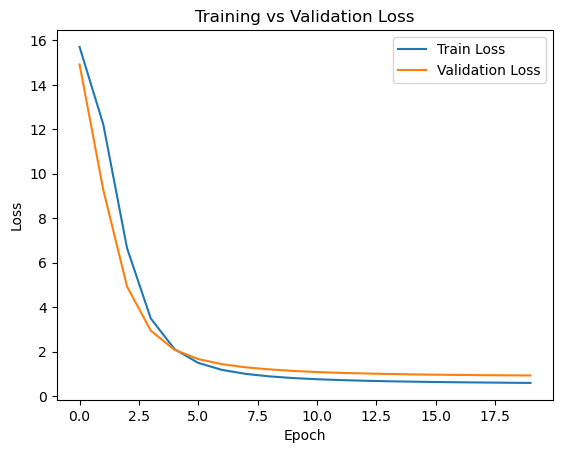

In [57]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

In [81]:
raw_test_ds = tf.data.Dataset.from_tensor_slices(
    (
        {
            "Input-user": test_data_user,
            "Input-book": test_data_book
        },
        test_df['rating']
    )
)

test_ds = raw_test_ds.map(lambda x, y: x).batch(256)
test_labels = raw_test_ds.map(lambda x, y: y)

In [75]:
predictions = model.predict(test_ds)

  1/767 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step

767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [89]:
list_preds = list(predictions.reshape(-1, ))
list_test_labels = list(test_labels.as_numpy_iterator())

In [92]:
for i, pred in enumerate(list_preds):
    print(f"Label: {list_test_labels[i]} --> Pred: {pred:.2f}")

    if i == 10:
        break


Label: 5 --> Pred: 4.90
Label: 4 --> Pred: 3.59
Label: 3 --> Pred: 3.21
Label: 5 --> Pred: 4.07
Label: 3 --> Pred: 3.43
Label: 3 --> Pred: 4.07
Label: 3 --> Pred: 3.25
Label: 4 --> Pred: 4.70
Label: 3 --> Pred: 4.39
Label: 5 --> Pred: 4.43
Label: 5 --> Pred: 4.08


_____________

___________

_________

In [4]:
!pwd

/mnt/e/Deep Learning/src/Text Classification, Using Embeddings, and Recommender Systems


In [3]:
!head -n 1 "/mnt/e/Deep Learning/data/ratings.csv" > "/mnt/e/Deep Learning/data/header.csv"

In [5]:
!tail -n +2 "/mnt/e/Deep Learning/data/ratings.csv" > "/mnt/e/Deep Learning/data/temp.csv"

In [7]:
!head "/mnt/e/Deep Learning/data/ratings.csv"

book_id,user_id,rating
1,314,5
1,439,3
1,588,5
1,1169,4
1,1185,4
1,2077,4
1,2487,4
1,2900,5
1,3662,4


In [8]:
!shuf "/mnt/e/Deep Learning/data/temp.csv" > "/mnt/e/Deep Learning/data/shuffeld.csv"

In [9]:
!head "/mnt/e/Deep Learning/data/shuffeld.csv"

5762,21837,3
5823,37700,5
151,44963,4
6022,46872,5
3735,38617,4
1218,41014,4
9645,16088,3
7209,48935,5
4301,4210,5
4550,38434,5


In [10]:
!wc -l "/mnt/e/Deep Learning/data/shuffeld.csv"

981756 /mnt/e/Deep Learning/data/shuffeld.csv


In [11]:
!split -l $((981756 * 80 / 100)) "/mnt/e/Deep Learning/data/shuffeld.csv"

In [12]:
!cat "/mnt/e/Deep Learning/data/header.csv" "/mnt/e/Deep Learning/src/Text Classification, Using Embeddings, and Recommender Systems/xaa" > "/mnt/e/Deep Learning/data/train.csv"

In [13]:
!cat "/mnt/e/Deep Learning/data/header.csv" "/mnt/e/Deep Learning/src/Text Classification, Using Embeddings, and Recommender Systems/xab" > "/mnt/e/Deep Learning/data/test.csv"

In [14]:
! rm "/mnt/e/Deep Learning/data/header.csv" "/mnt/e/Deep Learning/data/temp.csv" "/mnt/e/Deep Learning/data/shuffeld.csv" "/mnt/e/Deep Learning/src/Text Classification, Using Embeddings, and Recommender Systems/xaa" "/mnt/e/Deep Learning/src/Text Classification, Using Embeddings, and Recommender Systems/xab"

In [15]:
!wc -l "/mnt/e/Deep Learning/data/test.csv"

196353 /mnt/e/Deep Learning/data/test.csv


In [16]:
!wc -l "/mnt/e/Deep Learning/data/train.csv"

785405 /mnt/e/Deep Learning/data/train.csv


In [1]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Input, Embedding, Flatten, Dot
from keras.losses  import MeanSquaredError
from keras.optimizers import AdamW
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau, TensorBoard


I0000 00:00:1780742725.226357  184710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780742725.476256  184710 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780742728.325427  184710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def create_csv_dataset(file_path):
    record = [tf.int64, tf.int64, tf.int32]
    dataset = tf.data.experimental.CsvDataset(file_path, record, header=True)
    dataset = dataset.map(lambda *x: ((x[0], x[1]), x[2]))
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(512)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [3]:
train_data = create_csv_dataset("/mnt/e/Deep Learning/data/train.csv")

W0000 00:00:1780742732.627085  184710 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# After .batch: 

(
    (
        [book_id1, book_id2, ..., book_id512],
        [user_id1, user_id2, ..., user_id512]
    ),
    [rating1, rating2, ..., rating512]
)

In [4]:
for data in train_data.take(1):
    features, ratings = data
    book_ids, user_ids = features

    print("book id:", book_ids[0].numpy())
    print("user id:", user_ids[0].numpy())
    print("rating:", ratings[0].numpy())
    break

book id: 4390
user id: 33716
rating: 2


In [5]:
ds = create_csv_dataset("/mnt/e/Deep Learning/data/ratings.csv")
test_data = create_csv_dataset("/mnt/e/Deep Learning/data/test.csv")

In [6]:
user_id_set = set()
book_id_set = set()

for data in ds:
    book_ids = data[0][0]
    user_ids = data[0][1]

    book_id_set.update(book_ids.numpy())
    user_id_set.update(user_ids.numpy())


In [7]:
len(user_id_set)

53424

In [8]:
len(book_id_set)

10000

In [9]:
tf.data.experimental.cardinality(train_data).numpy()

np.int64(-2)

In [10]:
count = 0

for _ in train_data:
    count += 1

print(count)

1534


In [11]:
count = 0

for _ in test_data:
    count += 1

print(count)

384


# Method 1 (dot)

In [48]:
input_book = Input(shape=(1,), name="Input-book")
embedding_book = Embedding(
    input_dim=len(book_id_set) + 1,
    output_dim=5,
    name="Book-Embedding"
)(input_book)

book_vec = Flatten()(embedding_book)

input_user = Input(shape=(1,), name="Input-user")
embedding_user = Embedding(
    input_dim=len(user_id_set) + 1,
    output_dim=5,
    name="User-Embedding"
)(input_user)

user_vec = Flatten()(embedding_user)

output = Dot(axes=1)([book_vec, user_vec])


model_1 = Model(
    inputs=[input_book, input_user],
    outputs=output
)

In [ ]:
model_1.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanSquaredError)

In [49]:
model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input-book          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-user          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Book-Embedding      │ (None, 1, 5)      │     50,005 │ Input-book[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User-Embedding      │ (None, 1, 5)      │    267,125 │ Input-user[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 5)         │          0 │ Book-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 5)         │          0 │ User-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 1)         │          0 │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 317,130 (1.21 MB)

 Trainable params: 317,130 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.1)

In [ ]:
history = model_1.fit(train_data, epochs=30, validation_data=test_data, callbacks=[reduce_lr, TensorBoard(log_dir="/mnt/e/Deep Learning/log/1-dot")])

Epoch 1/30


   1525/Unknown 8s 5ms/step - loss: 15.8245

/home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 15.7616 - val_loss: 15.3471 - learning_rate: 0.0010
Epoch 2/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 12.9610 - val_loss: 10.2413 - learning_rate: 0.0010
Epoch 3/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7.5063 - val_loss: 5.6074 - learning_rate: 0.0010
Epoch 4/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.9816 - val_loss: 3.2590 - learning_rate: 0.0010
Epoch 5/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 2.3354 - val_loss: 2.2028 - learning_rate: 0.0010
Epoch 6/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.5871 - val_loss: 1.6958 - learning_rate: 0.0010
Epoch 7/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.2127 - val_loss: 1.4234 - learning_rate: 0.0010
Epoch 8/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 1.0040 - val_loss: 1.2609 - learning_rate: 0.0010
Epoch 9/30
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.8766 - val_loss: 1.1556 - learning_rate: 0.0

# Method 2(Deep Embedings)

In [13]:
input_book = Input(shape=(1,), name="Input-book")
embedding_book = Embedding(
    input_dim=len(book_id_set) + 1,
    output_dim=5,
    name="Book-Embedding"
)(input_book)

book_vec = Flatten()(embedding_book)
out1 = tf.keras.layers.Dense(10, activation='relu')(book_vec)

book_vec = Flatten()(embedding_book)

input_user = Input(shape=(1,), name="Input-user")
embedding_user = Embedding(
    input_dim=len(user_id_set) + 1,
    output_dim=5,
    name="User-Embedding"
)(input_user)

user_vec = Flatten()(embedding_user)
out2 = tf.keras.layers.Dense(10, activation='relu')(user_vec)

output = Dot(axes=1)([out1, out2])


model_2 = Model(
    inputs=[input_book, input_user],
    outputs=output
)

In [14]:
model_2.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanSquaredError)

In [15]:
model_2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input-book          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-user          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Book-Embedding      │ (None, 1, 5)      │     50,005 │ Input-book[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User-Embedding      │ (None, 1, 5)      │    267,125 │ Input-user[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 5)         │          0 │ Book-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 5)         │          0 │ User-Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │         60 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │         60 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 317,250 (1.21 MB)

 Trainable params: 317,250 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model_2.fit(train_data, epochs=20, validation_data=test_data, callbacks=[reduce_lr, TensorBoard(log_dir="/mnt/e/Deep Learning/log/2_deep-dot")])

Epoch 1/20


/home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/keras/src/callbacks/tensorboard.py:680: UserWarning: Model failed to serialize as JSON. Ignoring... MeanSquaredError.get_config() missing 1 required positional argument: 'self'
  warnings.warn(f"Model failed to serialize as JSON. Ignoring... {exc}")


   1528/Unknown 8s 4ms/step - loss: 6.3028

/home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 2.6077 - val_loss: 0.7478 - learning_rate: 0.0010
Epoch 2/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.7115 - val_loss: 0.7232 - learning_rate: 0.0010
Epoch 3/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.6823 - val_loss: 0.7129 - learning_rate: 0.0010
Epoch 4/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.6663 - val_loss: 0.7085 - learning_rate: 0.0010
Epoch 5/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.6556 - val_loss: 0.7058 - learning_rate: 0.0010
Epoch 6/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6462 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 7/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6335 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 8/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.6127 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 9/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.5880 - val_loss: 0.7261 - learning_rate: 0.0010
Ep

In [17]:
%load_ext tensorboard
%tensorboard --logdir "/mnt/e/Deep Learning/log"

ERROR: Timed out waiting for TensorBoard to start. It may still be running as pid 188234.